In [73]:
import matplotlib.pyplot as plt
import torch
import torchaudio
import numpy as np
import os

In [225]:
class Noise(torch.nn.Module):
    def __init__(self, N=440):
        super().__init__()
        self.N = N
        self.b = torch.nn.Parameter(torch.rand(N))

    def forward(self):
        return self.b * 2 - 1


class Phasor(torch.nn.Module):
    def __init__(self, N=440):
        super().__init__()
        self.N = N

    def forward(self):
        return torch.fft.fftfreq(self.N)


class Sine(torch.nn.Module):
    def __init__(self, N=440, min_freq=0.1, max_freq=100):
        super().__init__()
        self.N = N
        self.p = Phasor(N)
        range = max_freq - min_freq
        omega = torch.rand(1) * range + min_freq
        self.omega = torch.nn.Parameter(omega)

    def forward(self):
        return torch.sin(self.p() * 2 * torch.pi * self.omega)

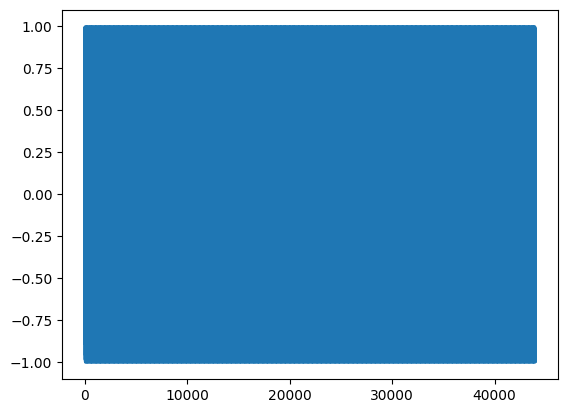

In [174]:
steps = 100
N = 480
fs = N * 50
y = []

osc = Sine()

for _ in range(steps):
  y.append(osc())

y = torch.cat(y)
plt.plot(y.detach())

torchaudio.save("jazz0.wav", y, fs)

jazz_out/jazz1-steps1000-lr0.1-N300-fs12000.wav


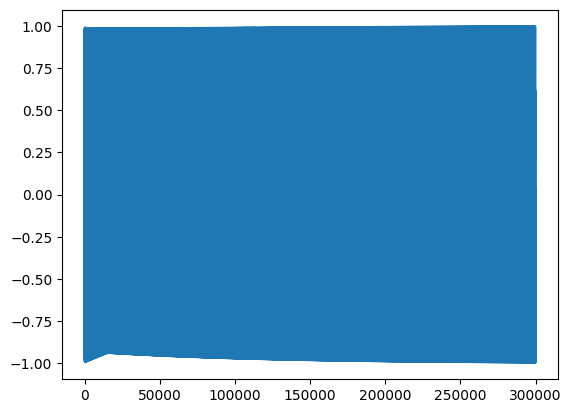

In [55]:
steps = 1000
lr = 0.1
N = 300
fs = 12000
audio = []

osc = Sine(N)
noise = Noise(N)

optimizer = torch.optim.SGD(noise.parameters(), lr)
mse = torch.nn.MSELoss()

target = osc()

for _ in range(steps):
  y = noise()
  audio.append(y)
  loss = mse(y, target)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


audio = torch.cat(audio)
plt.plot(audio.detach())
file = f"jazz_out/jazz1-steps{steps}-lr{lr}-N{N}-fs{fs}.wav"
torchaudio.save(file, audio, fs)
print(file)

jazz_out/jazz1-steps1000-lr0.1-N300-fs12000.wav


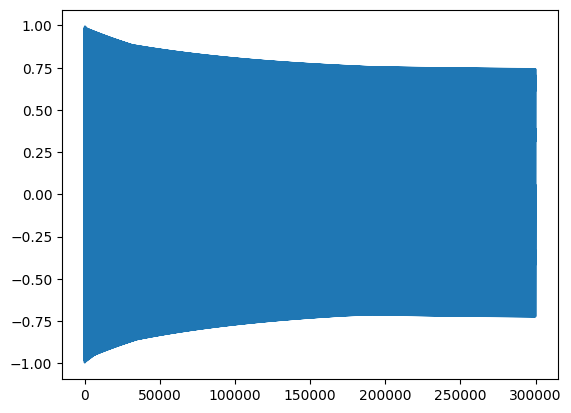

In [68]:
steps = 1000
lr = 0.1
N = 300
fs = 12000
audio = []

osc = Sine(N)
noise = Noise(N)

optimizer = torch.optim.SGD(noise.parameters(), lr)
mse = torch.nn.MSELoss()

with torch.no_grad():
  target = osc()

for _ in range(steps):
  y = noise()
  audio.append(y)
  loss = mse(y, target)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


audio = torch.cat(audio)
plt.plot(audio.detach())
file = f"jazz_out/jazz1-steps{steps}-lr{lr}-N{N}-fs{fs}.wav"
torchaudio.save(file, audio, fs)
print(file)

790.1009521484375
786.9437255859375
783.7990112304688
780.6669921875
777.54736328125
774.440185546875
771.3455810546875
768.2633056640625
765.193359375
762.1356201171875
759.090087890625
756.0567626953125
753.0355834960938
750.0264892578125
747.0294799804688
744.0443115234375
741.0711669921875
738.1099243164062
735.160400390625
732.2228393554688
729.296875
726.3825073242188
723.47998046875
720.5889892578125
717.70947265625
714.8414306640625
711.98486328125
709.1397094726562
706.305908203125
703.4833984375
700.6723022460938
697.8723754882812
695.083740234375
692.3060913085938
689.5396118164062
686.7843017578125
684.0398559570312
681.3065185546875
678.583984375
675.8722534179688
673.1715087890625
670.4815063476562
667.8021850585938
665.1336059570312
662.475830078125
659.8286743164062
657.1920776367188
654.5658569335938
651.9501342773438
649.3449096679688
646.7501220703125
644.165771484375
641.5916137695312
639.02783203125
636.474365234375
633.9309692382812
631.397705078125
628.8746337890

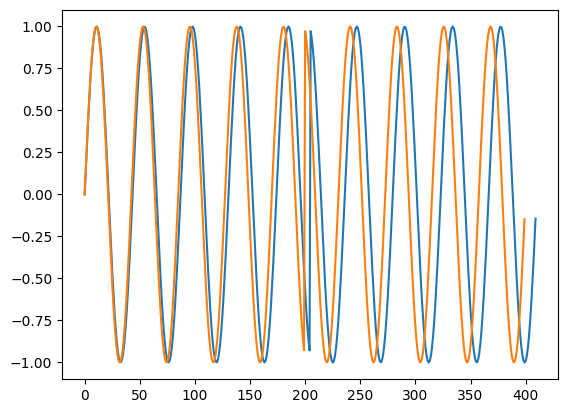

jazz_out/jazz2_0-steps10000-lr0.001-N400-fs44100.wav


In [227]:
steps = 10000
lr = 0.001
N = 400
fs = 44100
audio = []

osc1 = Sine(N)
osc2 = Sine(N+10)

optimizer = torch.optim.SGD(osc1.parameters(), lr)
mse = torch.nn.MSELoss()

with torch.no_grad():
  target = osc2()

for step in range(steps):
  y = osc1()
  audio.append((y) * 0.5)
  loss = mse(osc1.omega, osc2.omega)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if step % steps // 10:
    print(loss.item())

for i, samp in enumerate(audio):
   samp = samp + target[i%len(target)] * 0.5
   

audio = torch.cat(audio)
plt.plot(target)
plt.plot(y.detach())
plt.show()


out_dir = "jazz_out"
file = file
out_dir = "jazz_out"
base_name = f"jazz2"
params = f"steps{steps}-lr{lr}-N{N}-fs{fs}"   # or whatever you want here

# Find next index
file_idx = 0
while True:
    candidate = os.path.join(out_dir, f"{base_name}_{file_idx}.wav")
    if not os.path.exists(candidate):
        break
    file_idx += 1

# Re‑build the filename with params in the stem, before the .wav
stem, ext = os.path.splitext(candidate)  # e.g., "jazz2-..._1.wav" → "jazz2-..._1", ".wav"
file = f"{stem}-{params}{ext}"           # e.g., "jazz2-..._1_omega1_phi2.wav"

torchaudio.save(file, audio.unsqueeze(0), fs)
print(file)

0.8248016238212585
0.6981121301651001
0.5908821225166321
0.500122606754303
0.4233037531375885
0.3582842946052551
0.30325183272361755
0.25667235255241394
0.21724747121334076
0.18387827277183533
0.1556345671415329
0.1317290961742401
0.1114955022931099
0.0943697914481163
0.07987459003925323
0.06760585308074951
0.05722159519791603
0.048432353883981705
0.04099314659833908
0.03469659760594368
0.029367202892899513
0.02485639974474907
0.021038461476564407
0.017806952819228172
0.015071804635226727
0.012756776064634323
0.010797334834933281
0.00913886446505785
0.0077351354993879795
0.0065470184199512005
0.005541395395994186
0.00469023734331131
0.003969816491007805
0.0033600530587136745
0.002843949245288968
0.0024071186780929565
0.002037385245785117
0.0017244428163394332
0.0014595681568607688
0.0012353785568848252
0.0010456242598593235
0.000885016459506005
0.7543967366218567
0.6385213732719421
0.5404444932937622
0.45743221044540405
0.3871706426143646
0.327701210975647
0.2773663401603699
0.23476284

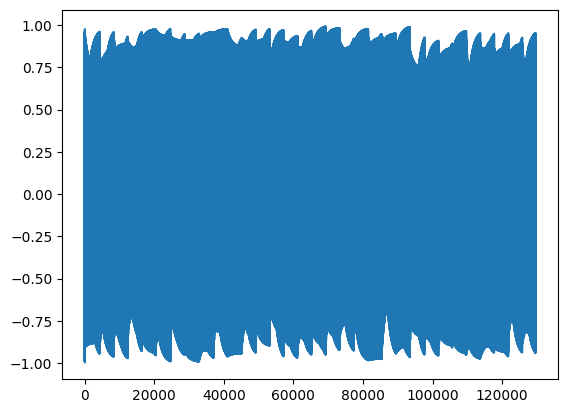

In [258]:
ITERATIONS = 32
lr = 1
N = 100
fs = 12000
audio = []

noise = Noise(N)

optimizer = torch.optim.SGD(noise.parameters(), lr)
mse = torch.nn.MSELoss()

for _ in range(ITERATIONS):
  with torch.no_grad():
    target = Noise(N)()

  loss = mse(noise(), target)
  while loss.item() > 0.001:
    y = noise()
    audio.append(y)
    # audio.append((y + target) * 0.5)
    loss = mse(y, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss.item())

audio = torch.cat(audio)
plt.plot(audio.detach())


out_dir = "jazz_out"
base_name = f"jazz3"
params = f"lr{lr}-N{N}-fs{fs}"   # or whatever you want here

# Find next index
file_idx = 0
while True:
    candidate = os.path.join(out_dir, f"{base_name}_{file_idx}.wav")
    if not os.path.exists(candidate):
        break
    file_idx += 1

# Re‑build the filename with params in the stem, before the .wav
# stem, ext = os.path.splitext(candidate)  # e.g., "jazz2-..._1.wav" → "jazz2-..._1", ".wav"
# file = f"{stem}-{params}{ext}"           # e.g., "jazz2-..._1_omega1_phi2.wav"

torchaudio.save(candidate, audio.unsqueeze(0), fs)
print(candidate)